# DS4D Assignment 2: Exploring a real-word dataset

This is an individual assignment working with the real world data you have been assigned. You are asked to do the following:
* Describe: explain the data and context
* Explore: visualisations, descriptions, descriptive/inferential statistics
* Reflect & Hypothesise: reflect on what was found in the data and form hypotheses that can be tested in future 

We also ask you to describe any ways you use AI in completing the assignment: for text and code generation, translation, ideation etc. If you do use AI, how have you applied your own creativity, programming skills, and critical thinking?

Your submission will be assessed by how well it demonstrates the learning objectives of the course:
* LO1 Program: Identify and deploy strategies for writing, understanding and managing computer programs using Python.
* LO2 Data: The ability to wrangle, analyse, learn from and visualise a range of data, in a way that demonstrates its relevance to particular contexts of enquiry.
* LO3 Communicate: Communicate around socially relevant issues, supported by the use of multiple data sources and appropriate analysis.


Note that your description of how you used AI will help us determine how well your submission demonstrates your own learning above and beyond the use of AI.


# Whale Sound Classification Project

This notebook is part of a project focused on classifying whale sounds using machine learning techniques. In this notebook, we perform data loading, preprocessing, feature extraction, unsupervised clustering, and supervised classification on whale sound data. The goal is to understand patterns in different whale vocalizations and use these patterns to predict sound classifications for new audio data.

Please refer to the `README.md` file for detailed information about the project structure, data sources, and setup instructions. The `README.md` includes a link to the audio data files (whale_sounds.zip), as well as an overview of the processing steps and dependencies. For smooth execution, unzip the audio data file and place the extracted files in the designated folder before running this notebook.

This notebook follows these steps:
1. **Data Understanding**: Load and describe the audio data.
2. **Preprocessing**: Clean and preprocess audio data for analysis.
3. **Feature Extraction**: Extract relevant features, such as MFCC and frequency stats.
4. **Clustering and Classification**: Use KMeans clustering to create pseudo-labels and Random Forest for classification.
5. **Reflection and Analysis**: Summarize findings and insights based on model performance and audio patterns.

This document serves as an interactive exploration, while the `README.md` provides a comprehensive guide to the project.


## Introduction

[[[[[ **REPLACE THIS TEXT BLOCK** to introduce and **DESCRIBE** your dataset. Every dataset is different, but you may want to describe where it is from, who collected it, how and why it was collected, what types of data it contains, any assumptions made in the data, and any other information you think is important ]]]]]

### 1. Basic information about the data set

The audio data used in this project comes from the **Watkins Marine Mammal Sound Database**, which is an archive of marine mammal recordings captured in various marine environments. The database contains approximately 2000 unique recordings of more than 60 species of marine mammals. Recordings were made by Watkins and Schevill as well as many others, including G. C. Ray, D. Wartzok, D. and M. Caldwell, K. Norris, and T. Poulter. Specifically, the dataset includes recordings of whale vocalizations, collected using underwater hydrophones.

### 2. Types of Data Contained

The primary data consists of sound recordings from different species of marine mammals, including whales, dolphins, and seals. Each recording is typically accompanied by detailed metadata, which includes: Species identification, Recording date and time, Geographic location, Environmental conditions (if available). What's more, there are some information on the identified species' vocalization types, like songs, clicks, pulses, and whistles, which helps researchers understand their behavioral context.

Since Victoria Evans wants us to focus on low-frequency sounds, she has highlighted several species of baleen whales in the Watkins Marine Mammal Sound Database for us to study: blue whales, fin whales, humpback whales, right whales, and bowhead whales—all of which are characterized by low-frequency vocalizations. Among these species, humpback whales exhibit complex vocalizations with diverse frequencies and intricate patterns, including long sequences that vary over time, providing rich data for low-frequency analysis.



### 3. Design concept

When listening to the audio recordings of these baleen whale species in the database, there are many sounds that I cannot hear with my ears such as fin whales, making me feel as if I were deaf. After conducting research, I found that the frequency range of vibrations that the human ear can perceive is approximately 20-20,000 Hz. Some of the whale sounds exceed the minimum limit of what my ears can hear. However, I am so eager to experience these whale sounds that I started thinking about whether I could perceive them in another way.

It suddenly hitted me that some deaf people tend to experience sounds through touching. After research, I find that the range of vibration frequencies that the human body can perceive is typically between 1 Hz and 1000 Hz. This range is lower than the audible sound frequency range for humans (approximately 20 Hz to 20,000 Hz). The human body is particularly sensitive to low-frequency vibrations, especially within the 1 Hz to 100 Hz range, which is commonly used in tactile feedback technologies. I think this perception works well for these low-frequency whale datasets.

## Method

This study employs a cross-species clustering approach to classify and analyze vocalizations across different whale species. By extracting and analyzing MFCC (Mel-Frequency Cepstral Coefficients) and other spectral features from audio recordings, we group the vocal patterns into distinct clusters that may correspond to specific species or vocalization types. A K-means clustering algorithm is applied to discover inherent structures within the multi-species dataset, without relying on species labels, allowing us to examine natural similarities and differences in whale calls. 

Clustering serves as a preprocessing step to identify initial groupings in the data, which enhances the supervised learning model's classification accuracy by structuring complex patterns across species. Following clustering, a supervised learning model (Random Forest classifier) is trained on the clustered data to predict the species of new, unseen audio samples, which validates the model’s ability to generalize across diverse vocalization patterns. This method offers a scalable approach for identifying and monitoring whale species through acoustic signals, contributing valuable insights into design.

Running this command installs librosa/matplotlib/numpy/pandas/joblib libraries if they are not already installed.

In [1]:
!pip install librosa matplotlib numpy pandas joblib

  Using cached librosa-0.10.2.post1-py3-none-any.whl.metadata (8.6 kB)
  Using cached audioread-3.0.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached soundfile-0.12.1-py2.py3-none-manylinux_2_31_x86_64.whl.metadata (14 kB)
  Using cached soxr-0.5.0.post1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached librosa-0.10.2.post1-py3-none-any.whl (260 kB)
Using cached audioread-3.0.1-py3-none-any.whl (23 kB)
Using cached soundfile-0.12.1-py2.py3-none-manylinux_2_31_x86_64.whl (1.2 MB)
Using cached soxr-0.5.0.post1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (252 kB)


In [2]:
# Import necessary libraries
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import warnings
import scipy.signal as signal
import plotly.express as px
import os
import pandas as pd
import joblib

from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from ast import literal_eval  # Use more secure parsing methods


### Descriptive Analysis of Single Audio Sample


First, a single audio sample of a specific species, such as **humpback whales**, is selected and the audio characteristics are explored through data replication, descriptive statistical analysis, and preliminary analysis of that sample. This step helps us familiarize ourselves with the data structure, verify the absence of analytical methods, and observe the preliminary feature distribution.


In [3]:
# Load the audio file using a relative path
audio_path = "./audio/humpback_whale/humpback_whale_55113001.wav"
audio_data, sr = librosa.load(audio_path, sr=22050)

# Compute the mel spectrogram
mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sr, n_mels=128, fmax=8000)
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

# Extract features within a specific frequency range and apply KMeans clustering
frequency_range = (500, 1000)
idx_min = int(frequency_range[0] / (sr / 2) * mel_spectrogram.shape[0])
idx_max = int(frequency_range[1] / (sr / 2) * mel_spectrogram.shape[0])
feature_subset = mel_spectrogram_db[idx_min:idx_max, :].T

kmeans = KMeans(n_clusters=3, random_state=0).fit(feature_subset)
labels = kmeans.labels_

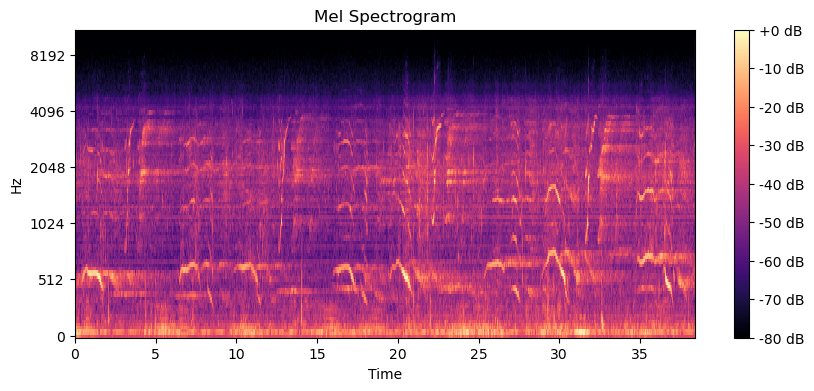

In [4]:
# Visualize the mel spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spectrogram_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.show()

This mel spectrogram displays the frequency distribution of a whale sound over time. Frequencies range from around 0 Hz up to 8192 Hz, covering both lower and mid-range frequencies, which are commonly found in whale vocalizations. The color intensity indicates the amplitude or loudness in decibels (dB), with lighter colors representing stronger intensities.

Notable observations include higher intensities (yellow and orange regions) around the lower frequency bands, below 1000 Hz, where most energy appears concentrated, especially between 0 and 40 dB. As frequencies increase, the intensity diminishes, with darker regions representing lower sound intensities, reaching down to -80 dB. This pattern suggests that the core acoustic energy in this whale sound is centered in the lower frequency bands, while higher frequencies have reduced energy and possibly represent background noise or harmonics.

#### Load Audio Data and Extract MFCC Features:
* The audio file is loaded using librosa, and 13 Mel Frequency Cepstral Coefficients (MFCCs) are extracted. MFCCs represent the short-term power spectrum of the sound, capturing its main characteristics.
* features is transposed so that each row represents a feature vector for a specific time segment.

In [5]:
# Load audio data and extract MFCC features
file_path = "./audio/humpback_whale/humpback_whale_55113001.wav" # Relative path of audio file
y, sr = librosa.load(file_path, sr=None)  # Loading audio file
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)  # 13-dimensional MFCC features were extracted
features = mfccs.T  # Transpose so that each row represents a feature vector for a time segment

Calculate Descriptive Statistics for Each MFCC Dimension

In [6]:
# Calculate descriptive statistics for each MFCC feature dimension
mean_mfcc = np.mean(features, axis=0)
std_mfcc = np.std(features, axis=0)
min_mfcc = np.min(features, axis=0)
max_mfcc = np.max(features, axis=0)

print("MFCC Mean:\n", mean_mfcc)
print("MFCC Standard Deviation:\n", std_mfcc)
print("MFCC Min:\n", min_mfcc)
print("MFCC Max:\n", max_mfcc)

MFCC Mean:
 [-201.77585    138.21086    -71.18498     56.041176    14.565734
    5.6674604    6.3307295   -3.3053353    6.092764     9.59736
    6.054233    12.408022    14.568572 ]
MFCC Standard Deviation:
 [27.837324 12.203671 15.350517 10.70915  10.183022  8.929938  8.891023
  7.807758  8.404339  9.485972 10.6114    8.632013 10.027101]
MFCC Min:
 [-263.5096     96.06198  -119.07034    18.424065  -16.891796  -21.929546
  -19.728928  -24.960236  -29.15348   -18.069378  -22.108076  -12.553097
  -18.0666  ]
MFCC Max:
 [-107.97177    178.5002      -6.3162394   86.32416     51.396194
   44.29596     34.36441     31.01276     34.818577    49.70671
   36.916313    34.40316     40.435966 ]


Calculate the Average Frequency Range of the Audio
* The Short-Time Fourier Transform (STFT) is computed to capture frequency characteristics over time.
* The mean and standard deviation of the STFT values are calculated across all time segments, yielding an overall frequency profile:
  * frequency_mean: the average amplitude across frequencies.
  * frequency_std: the spread of amplitudes across frequencies.
* These metrics provide a general overview of the audio's frequency distribution.

1. **MFCC Characteristics**:
   - The MFCC mean values range from -201.78 to 14.57, indicating that lower-order MFCC coefficients (e.g., MFCC_0) are predominantly negative, reflecting the audio’s concentration of energy in lower frequencies.
   - The standard deviations (e.g., 27.84 for MFCC_0) suggest considerable variation across certain MFCC dimensions, possibly showing diverse sound features in the audio.


2. **MFCC Extremes**:
   - The minimum and maximum MFCC values across dimensions (e.g., -263.51 to -107.97 in MFCC_0) indicate large fluctuations in the lower frequency bands, which aligns with the tendency for energy to cluster in low-frequency ranges typical of whale sounds.


3. **Frequency Characteristics**:
   - The frequency mean (0.566) and standard deviation (0.829) suggest the audio’s frequency content is relatively low and stable, characteristic of whale sounds that generally fall within low-frequency ranges.

Overall, these statistics highlight the audio’s strong low-frequency presence and MFCC energy distribution, aligning with expected whale sound features and supporting further clustering or classification analysis based on these traits.


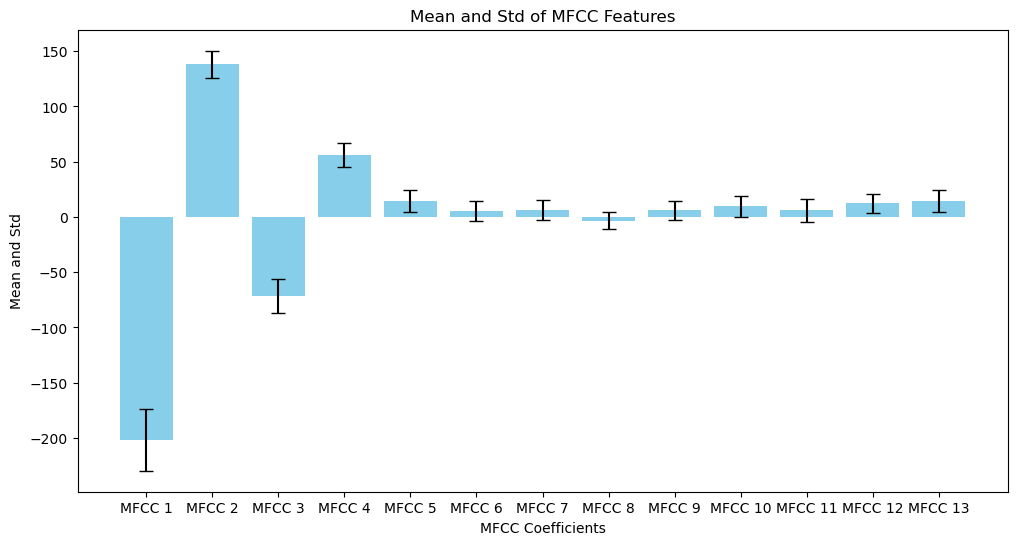

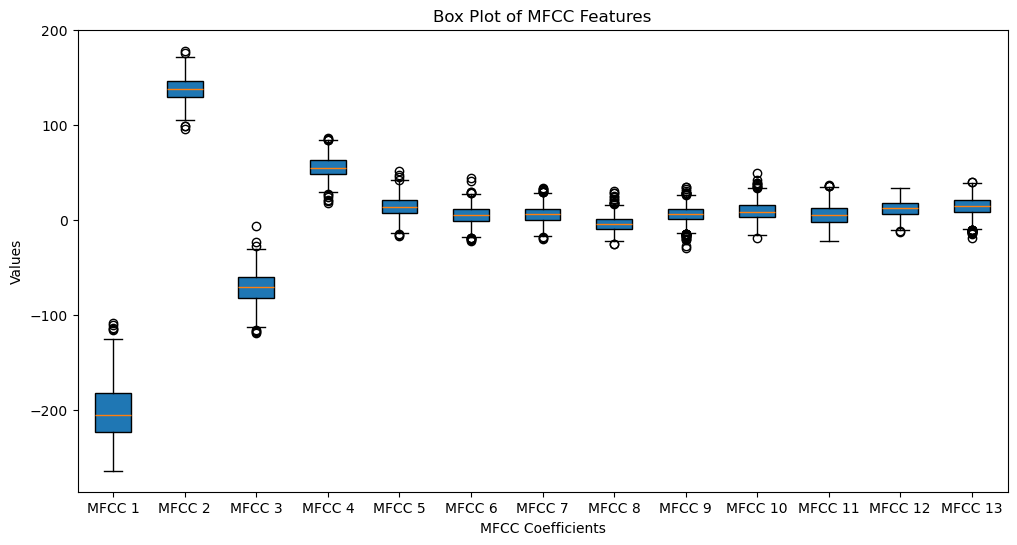

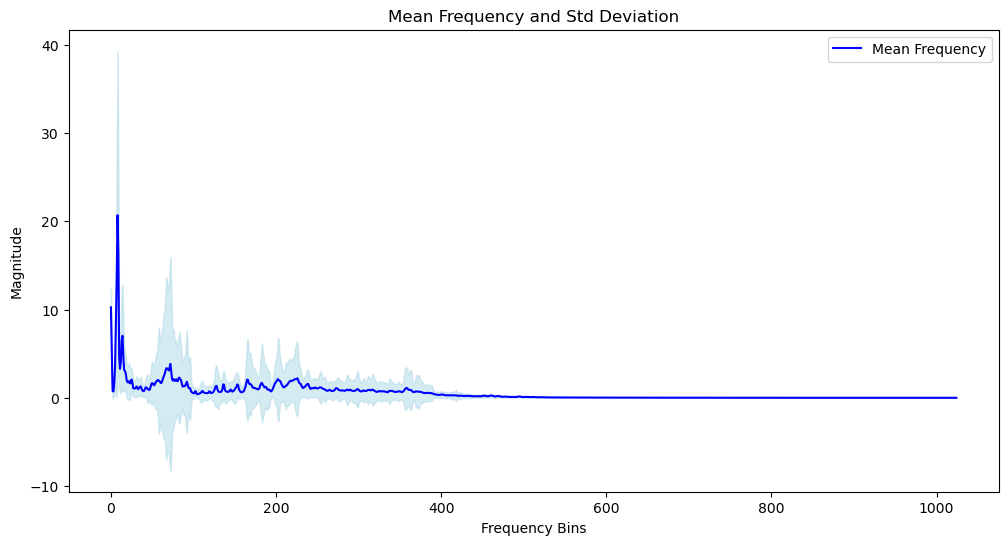

In [7]:
# Bar chart of mean and standard deviation of MFCC features
plt.figure(figsize=(12, 6))
x = np.arange(len(mean_mfcc))
plt.bar(x, mean_mfcc, yerr=std_mfcc, capsize=5, color="skyblue")
plt.xlabel("MFCC Coefficients")
plt.ylabel("Mean and Std")
plt.title("Mean and Std of MFCC Features")
plt.xticks(ticks=x, labels=[f"MFCC {i+1}" for i in range(len(mean_mfcc))])
plt.show()

# Box diagram of MFCC features
plt.figure(figsize=(12, 6))
plt.boxplot(features, vert=True, patch_artist=True)
plt.xlabel("MFCC Coefficients")
plt.ylabel("Values")
plt.title("Box Plot of MFCC Features")
plt.xticks(ticks=x + 1, labels=[f"MFCC {i+1}" for i in range(len(mean_mfcc))])
plt.show()

# The distribution of mean and standard deviation of the spectrum
stft = np.abs(librosa.stft(y))
frequency_mean = np.mean(stft, axis=1)
frequency_std = np.std(stft, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(frequency_mean, label="Mean Frequency", color="blue")
plt.fill_between(
    range(len(frequency_mean)),
    frequency_mean - frequency_std,
    frequency_mean + frequency_std,
    color="lightblue",
    alpha=0.5,
)
plt.xlabel("Frequency Bins")
plt.ylabel("Magnitude")
plt.title("Mean Frequency and Std Deviation")
plt.legend()
plt.show()

### Conclusions from Humpback Whale Audio Data Analysis

#### 1. MFCC Features (Mean and Standard Deviation)
- The first few MFCC coefficients, especially MFCC 1 and 2, show significantly higher values and variability, capturing the main characteristics of the whale's call.
- Subsequent MFCC coefficients exhibit lower values, indicating that the main features of the sound are represented in the initial coefficients.
- This suggests that the first few MFCCs are the most relevant for distinguishing and analyzing whale sounds.

#### 2. MFCC Box Plot
- There is notable variation and outliers in MFCC 1 and 2, indicating unique patterns or variability within the call.
- The mid-range MFCCs show more stability, suggesting a consistent sound pattern.

#### 3. Frequency Spectrum (Mean and Standard Deviation)
- Most energy is concentrated in the lower frequencies, with high variance initially, stabilizing over higher frequencies.
- The low-frequency focus aligns with whale vocalizations, which use low frequencies for long-distance communication.


The clustering itself is used as part of the data preprocessing. By grouping or dimensionality reduction of data, supervised learning model is used for classification or regression to improve the accuracy of the model.
So I apply PCA and KMeans clustering in clustering analysis for a single audio in order to:

**Dimensionality Reduction**: Reducing high-dimensional MFCC features to three dimensions makes it easier to visualize and analyze the data.

**Identify Audio Structure**: Even within a single audio file, there may be different sound patterns. Clustering helps to identify these internal structures, providing a reference for analyzing patterns in multiple audio files later.

**Visualization Purpose**: The 3D features after PCA allow us to visually observe the distribution of audio segments in feature space, helping us understand the audio structure. Different clusters may reveal distinct sound patterns or rhythms within the audio.

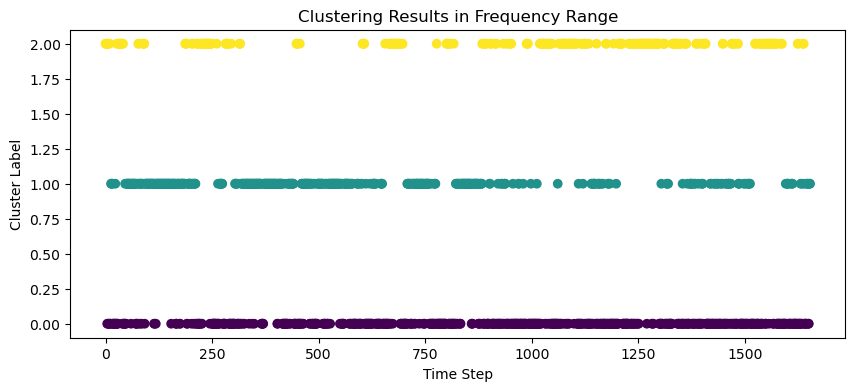

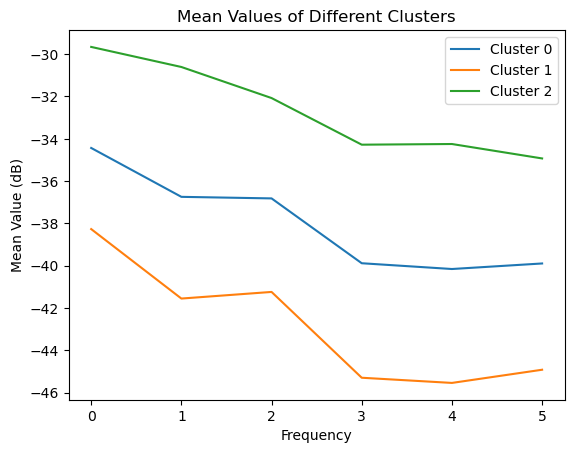

In [9]:
# Plot the clustering results
plt.figure(figsize=(10, 4))
plt.scatter(range(len(labels)), labels, c=labels, cmap="viridis")
plt.title("Clustering Results in Frequency Range")
plt.xlabel("Time Step")
plt.ylabel("Cluster Label")
plt.show()

# Plot the mean values of different clusters in the frequency range
for cluster_id in np.unique(labels):
    cluster_data = feature_subset[labels == cluster_id]
    cluster_mean = np.mean(cluster_data, axis=0)

    plt.plot(cluster_mean, label=f"Cluster {cluster_id}")
plt.legend()
plt.title("Mean Values of Different Clusters")
plt.xlabel("Frequency")
plt.ylabel("Mean Value (dB)")
plt.show()

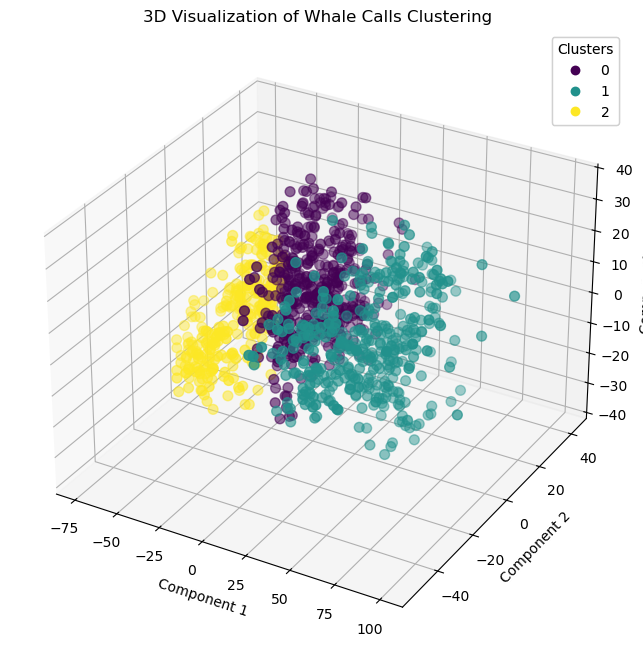

In [10]:
# Determine the dimension of the feature data
if features.shape[0] == 0:
    print("No features to visualize.")
else:
    # The features are reduced to three dimensions using PCA
    pca = PCA(n_components=3)
    features_3d = pca.fit_transform(features)

    # Cluster the data after dimensionality reduction
    kmeans = KMeans(n_clusters=3, random_state=0)
    labels = kmeans.fit_predict(features_3d)

    # Visualize the clustering results
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Draw points of different colors based on different clustering labels
    scatter = ax.scatter(
        features_3d[:, 0], features_3d[:, 1], features_3d[:, 2], c=labels, cmap="viridis", marker="o", s=50
    )

    # Add title and axis labels
    ax.set_title("3D Visualization of Whale Calls Clustering")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_zlabel("Component 3")

    # Show Legend
    legend = ax.legend(*scatter.legend_elements(), title="Clusters")
    ax.add_artist(legend)

    plt.show()

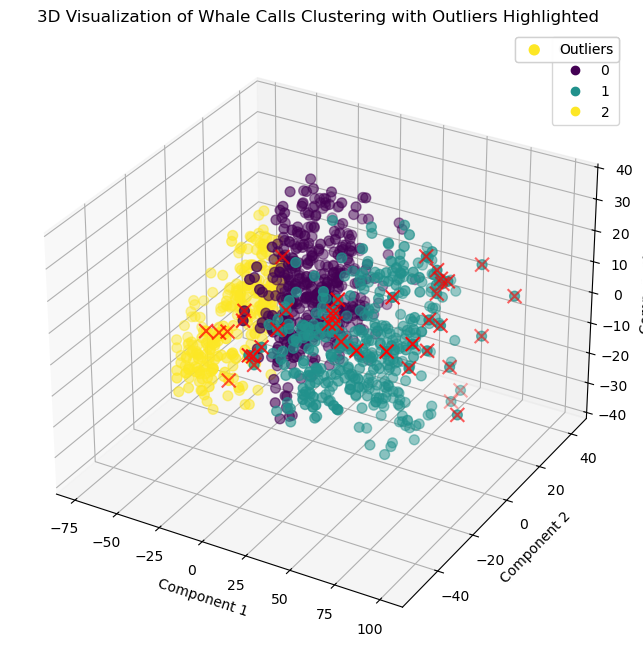

In [11]:
    # Calculate the distance of each point to its cluster center and identify outliers
    centers = kmeans.cluster_centers_
    distances = np.linalg.norm(features_3d - centers[labels], axis=1)
    threshold = np.mean(distances) + 2*np.std(distances)  # Use the mean distance + double standard deviation as the threshold
    outliers = np.where(distances > threshold)[0]  # Find the outlier index

    # Visualize clustering results and highlight outliers
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot normal points
    normal_points = ax.scatter(features_3d[:, 0], features_3d[:, 1], features_3d[:, 2],
                               c=labels, cmap='viridis', marker='o', s=50)

    # Plot outliers
    outlier_points = ax.scatter(features_3d[outliers, 0], features_3d[outliers, 1], features_3d[outliers, 2],
                                color='red', marker='x', s=100, label='Outliers')

    # Add title and axis labels
    ax.set_title("3D Visualization of Whale Calls Clustering with Outliers Highlighted")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_zlabel("Component 3")

    # Show Legend
    legend1 = ax.legend(*normal_points.legend_elements(), title="Clusters")
    legend2 = ax.legend(["Outliers"], loc="upper right")
    ax.add_artist(legend1)
    ax.add_artist(legend2)

    plt.show()

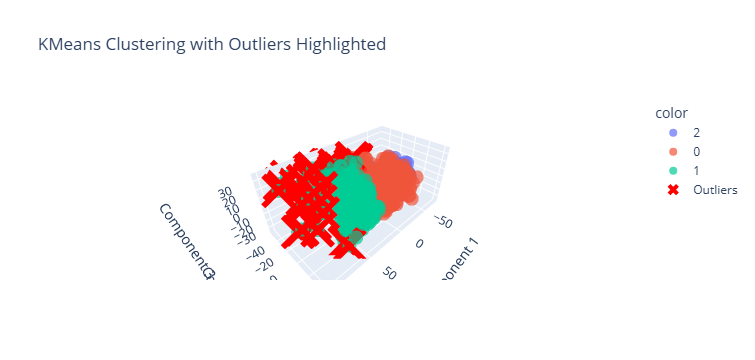

In [12]:
# Visualize clustering results and highlight outliers
fig = px.scatter_3d(
    x=features_3d[:, 0],
    y=features_3d[:, 1],
    z=features_3d[:, 2],
    color=labels.astype(str),
    title="KMeans Clustering with Outliers Highlighted",
    labels={"x": "Component 1", "y": "Component 2", "z": "Component 3"},
    opacity=0.7,
)

# Add a marker for outliers
fig.add_scatter3d(
    x=features_3d[outliers, 0],
    y=features_3d[outliers, 1],
    z=features_3d[outliers, 2],
    mode="markers",
    marker=dict(size=10, color="red", symbol="x"),
    name="Outliers",
)

fig.show()

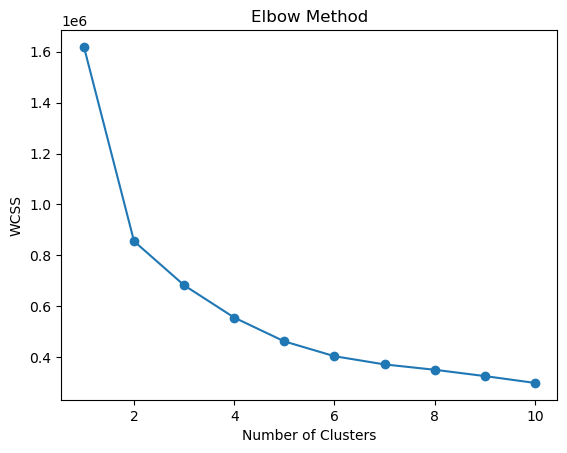

In [13]:
# Calculate WCSS for different cluster numbers
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(features_3d)
    wcss.append(kmeans.inertia_)

# Draw the elbow plot
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

Based on this elbow plot, an optimal number of clusters might be between 3 and 4.

In an elbow plot, the ideal number of clusters is often at the "elbow" point—where the curve shows a noticeable bend and begins to flatten out. In this plot:

- At 3 clusters, the curve's rate of descent noticeably slows.
- From 4 clusters onward, the reduction in WCSS becomes more gradual.

Thus, selecting 3 or 4 clusters could be suitable for observing clustering effectiveness.

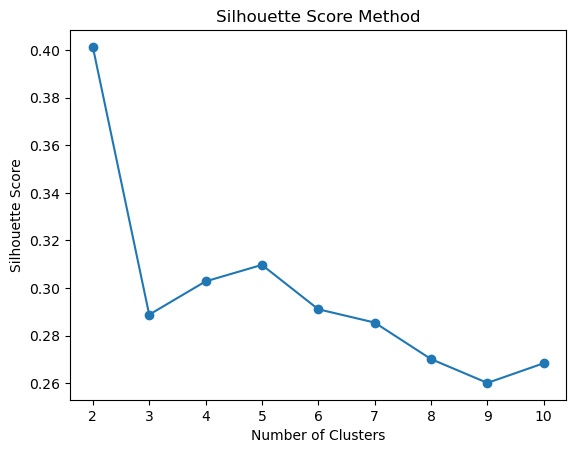

In [14]:
silhouette_scores = []
for i in range(2, 11):  # The contour coefficient requires at least 2 clusters
    kmeans = KMeans(n_clusters=i, random_state=0)
    labels = kmeans.fit_predict(features_3d)
    score = silhouette_score(features_3d, labels)
    silhouette_scores.append(score)

# Draw the contour coefficient diagram
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.title("Silhouette Score Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

From this silhouette score plot, the silhouette coefficient is highest at 2 clusters, with a score around 0.4. This indicates that the clustering quality is best with 2 clusters. However, since 2 clusters may be overly simplistic, 3 to 4 clusters could be considered to balance clustering detail and quality.

Based on the elbow method and silhouette analysis results, the recommendations are:

- **Primary Choice: 3 Clusters** — This is located at the elbow in the elbow plot and also has a relatively high silhouette score.
- **Secondary Choice: 4 Clusters** — If slightly more clustering complexity is desired, 4 clusters could be used, as the silhouette score remains reasonable.

In summary, 3 clusters is a stable and balanced choice.


Next, the same construction and analysis process is hybridized with multiple species (cross-species) audio samples to build a cross-species dataset. The update method is then applied to a wider range of audio data to update audio samples between different species. Finally, supervised learning models (such as random forests) are trained to make predictions about the species categories of new audio samples, thus verifying the model's generalization ability.

### Sample selection and data import

For this project, we selected several audio samples of each whale species from the Watkins Marine Mammal Sound Database. When selecting samples, different audio acquisition environments and recording conditions are considered to ensure the diversity and representation of the data. We processed each whale audio sample at a uniform sampling rate and imported the audio for feature analysis.

To ensure that the sample is representative enough:

* **Diversity**: Audio samples taken at different times and locations were selected in order to capture the acoustic diversity of the species.
* **Duration**: Choose a sample of moderate length to ensure stable features.
* **Quality**: Give priority to audio files with less background noise and clear sound for better feature extraction.


### Create a csv file for audios
Iterate through all subfolders recursively with code, automatically getting the path of each audio file and saving it to a CSV file. Because the file name contains the species name, the species information is automatically matched in the code.

In [16]:
# Specify the root folder for the audio files
root_folder = "./audio/"

# Build a data list containing file names, paths, and other metadata information
data = {
    "File_Name": [],
    "File_Path": [],
    "Species": [],  # Fill in species information based on the file name
}

# Traverse the root folder and all subfolders to locate audio files
for subdir, _, files in os.walk(root_folder):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(subdir, file)
            data["File_Name"].append(file)
            data["File_Path"].append(file_path)

            # Automatically fill in species information based on the file name
            if "fin" in file:
                data["Species"].append("Fin Whale")
            elif "humpback" in file:
                data["Species"].append("Humpback Whale")
            # Default species label for unidentified cases
            else:
                data["Species"].append("Bowhead Whale")  

# Convert to DataFrame
df = pd.DataFrame(data)

# Save as a CSV file
df.to_csv("whale_metadata.csv", index=False)
print("A CSV file is generated. The file name is: whale_metadata.csv")


A CSV file is generated. The file name is: whale_metadata.csv


### Batch audio processing
Load and pre-process audio in batches through audio processing libraries such as librosa to unify sampling rates, remove silent parts, extract features, etc., during pre-processing.

In [17]:
# Specify the root folder and output feature file
root_folder = "./audio/"
feature_data = {
    "File_Name": [],
    "Species": [],
    "MFCC_Mean": [],  # Store MFCC mean
    "MFCC_Std": [],   # Store MFCC standard deviation
    "MFCC_Min": [],   # Store MFCC minimum value
    "MFCC_Max": [],   # Store MFCC maximum value
}

# Load CSV file to get species information
metadata = pd.read_csv("whale_metadata.csv")

# Function to remove silence from audio
def remove_silence(y, sr, top_db=20):
    non_silent_intervals = librosa.effects.split(y, top_db=top_db)
    y_nonsilent = np.concatenate([y[start:end] for start, end in non_silent_intervals])
    return y_nonsilent

# Preprocessing function to extract MFCC features
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=22050)  # Set a consistent sampling rate
    y_nonsilent = remove_silence(y, sr)  # Remove silence
    mfccs = librosa.feature.mfcc(y=y_nonsilent, sr=sr, n_mfcc=13)

    # Calculate mean, standard deviation, minimum, and maximum, then convert to lists
    mfcc_mean = mfccs.mean(axis=1).tolist()
    mfcc_std = mfccs.std(axis=1).tolist()
    mfcc_min = mfccs.min(axis=1).tolist()
    mfcc_max = mfccs.max(axis=1).tolist()

    return mfcc_mean, mfcc_std, mfcc_min, mfcc_max

# Iterate over file paths in the CSV file
for _, row in metadata.iterrows():
    file_path = row["File_Path"]
    species = row["Species"]
    mfcc_mean, mfcc_std, mfcc_min, mfcc_max = extract_features(file_path)

    # Store each audio sample's features as strings
    feature_data["File_Name"].append(row["File_Name"])
    feature_data["Species"].append(species)
    feature_data["MFCC_Mean"].append(str(mfcc_mean))  # Convert to string
    feature_data["MFCC_Std"].append(str(mfcc_std))    # Convert to string
    feature_data["MFCC_Min"].append(str(mfcc_min))    # Convert to string
    feature_data["MFCC_Max"].append(str(mfcc_max))    # Convert to string

# Convert to DataFrame and save as CSV
features_df = pd.DataFrame(feature_data)
features_df.to_csv("whale_features.csv", index=False)
print("Audio features have been saved to whale_features.csv")


Audio features have been saved to whale_features.csv


### Descriptive Statistical Analysis
After importing and preprocessing multiple audio samples, an aggregate analysis is conducted for each whale species to gain a broader understanding. The average MFCC features and standard deviation for all audio samples of each species can be calculated and visualized to extract the overall characteristics of each whale's sound profile.


In [18]:
# Initialize an empty dictionary to store descriptive statistics
species_stats = {}

# Iterate over each species and calculate descriptive statistics for its MFCC features
for species, group in features_df.groupby("Species"):
    # Parse MFCC features from strings to numpy arrays
    mfcc_means = np.vstack(group["MFCC_Mean"].apply(literal_eval))
    mfcc_stds = np.vstack(group["MFCC_Std"].apply(literal_eval))

    # Calculate mean, standard deviation, minimum, and maximum for each whale species' MFCC features
    species_stats[species] = {
        "MFCC_Mean_Avg": np.mean(mfcc_means, axis=0),
        "MFCC_Mean_Std": np.std(mfcc_means, axis=0),
        "MFCC_Mean_Min": np.min(mfcc_means, axis=0),
        "MFCC_Mean_Max": np.max(mfcc_means, axis=0),
        "MFCC_Std_Avg": np.mean(mfcc_stds, axis=0),
        "MFCC_Std_Std": np.std(mfcc_stds, axis=0),
    }

# Convert descriptive statistics results to DataFrame for viewing
species_stats_df = pd.DataFrame.from_dict(species_stats, orient="index")
print("Descriptive statistical analysis for each whale species:")
print(species_stats_df)

# Save to CSV file if needed
species_stats_df.to_csv("species_descriptive_statistics.csv", index=True)


Descriptive statistical analysis for each whale species:
                                                    MFCC_Mean_Avg  \
Bowhead Whale   [-297.3150683316317, 185.7353910966353, -75.24...   
Fin Whale       [-661.132681274414, 68.64117736816407, 59.7616...   
Humpback Whale  [-357.8999839782715, 159.91855430603027, -9.40...   

                                                    MFCC_Mean_Std  \
Bowhead Whale   [62.75057122564881, 19.296445699302947, 29.176...   
Fin Whale       [60.56676698296877, 7.0654220244113635, 8.3142...   
Humpback Whale  [60.79753639526158, 28.91822435024154, 26.4191...   

                                                    MFCC_Mean_Min  \
Bowhead Whale   [-389.8009033203125, 145.0493927001953, -123.0...   
Fin Whale       [-750.3278198242188, 54.21293258666992, 49.419...   
Humpback Whale  [-468.4735412597656, 84.5495834350586, -67.272...   

                                                    MFCC_Mean_Max  \
Bowhead Whale   [-158.6658172607422, 215.00

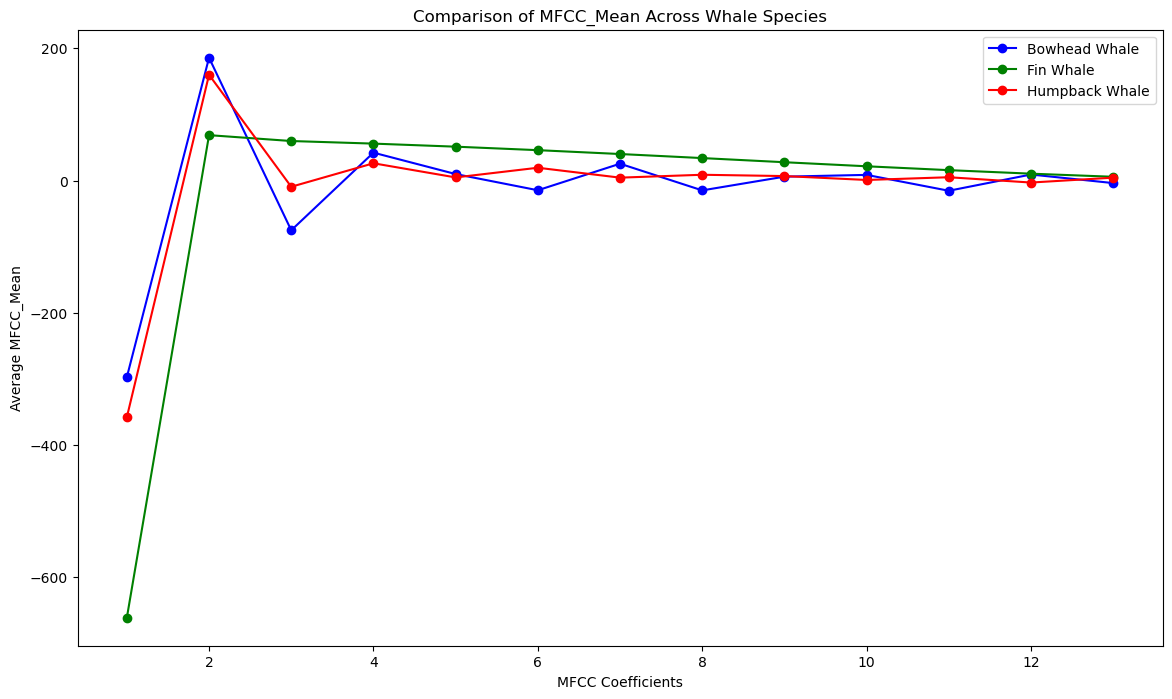

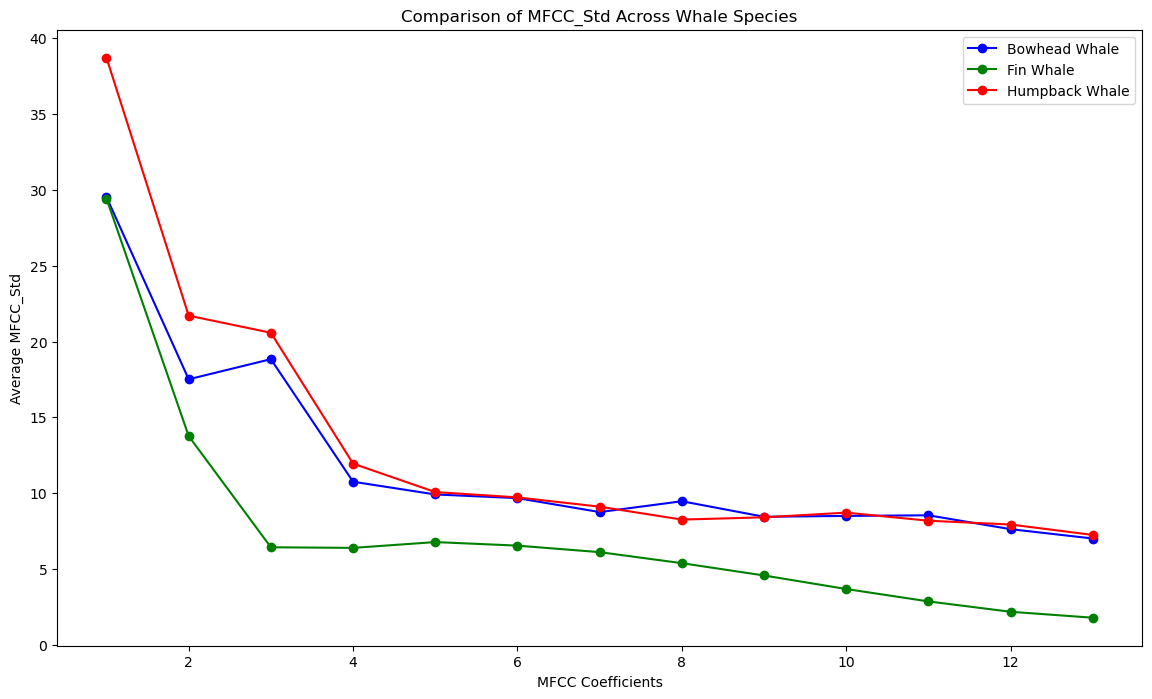

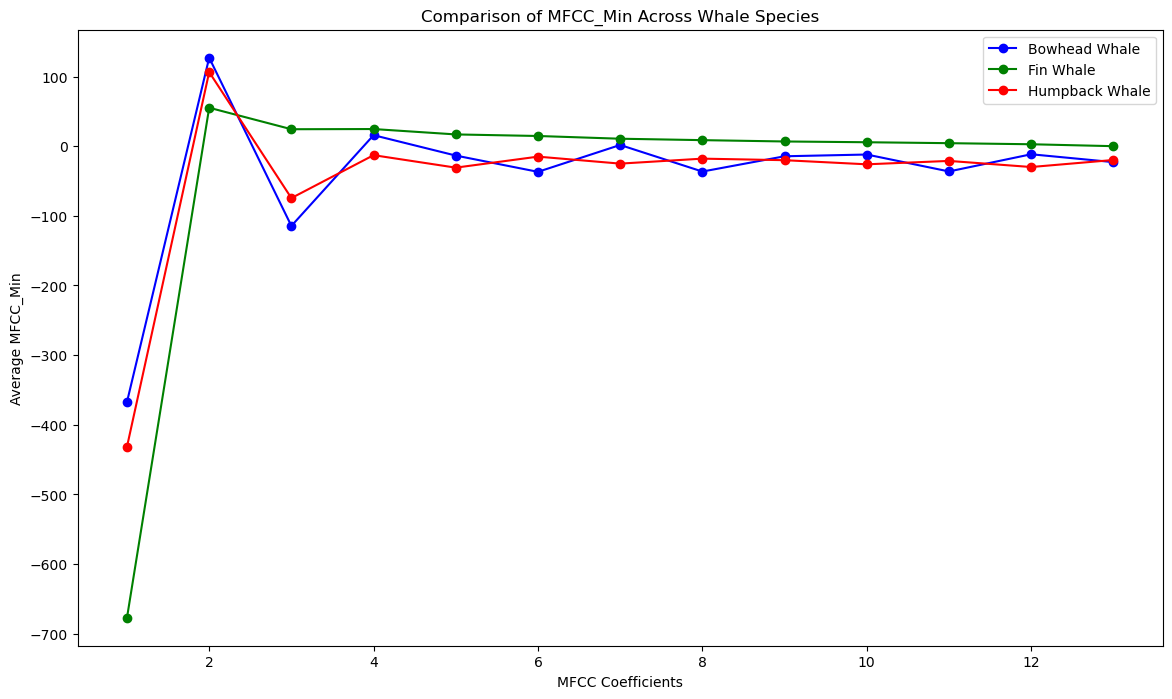

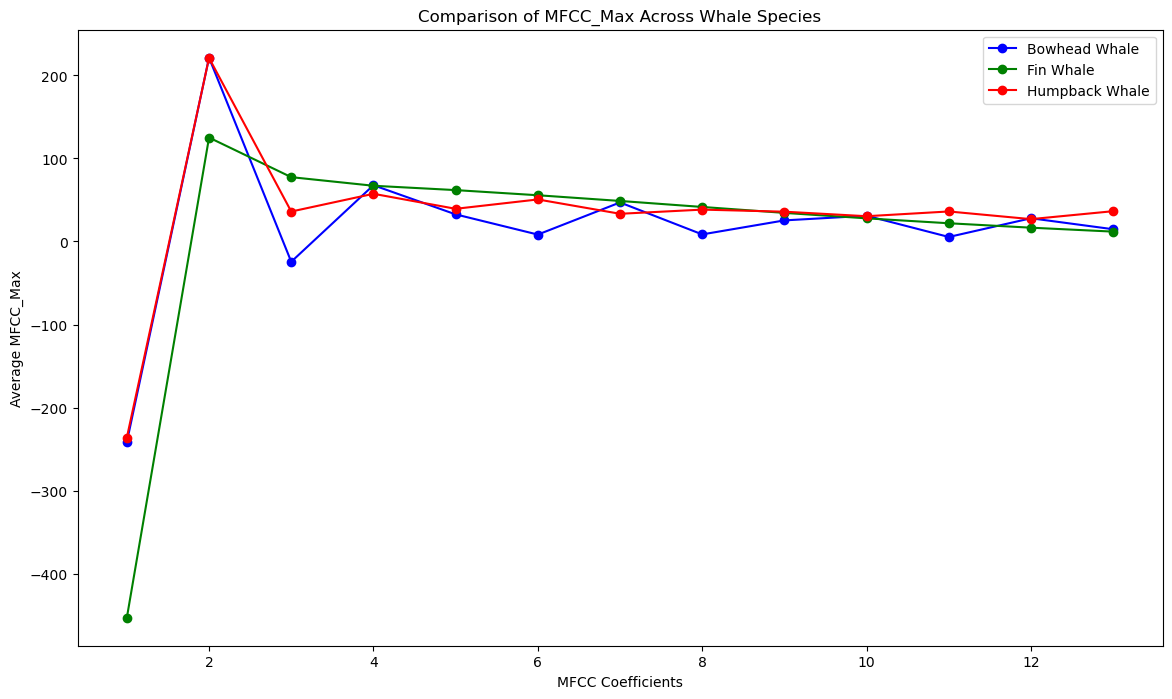

In [19]:
# Load statistical data
stats_df = pd.read_csv("whale_features.csv")
species_list = stats_df["Species"].unique()

# Define colors and legend names
colors = ["b", "g", "r"]
species_colors = dict(zip(species_list, colors))

# Define a list of statistical metric names
stats = ["MFCC_Mean", "MFCC_Std", "MFCC_Min", "MFCC_Max"]

# Iterate over each statistical metric and plot each separately
for stat in stats:
    plt.figure(figsize=(14, 8))
    for species in species_list:
        # Extract data for the corresponding metric
        stat_values = np.vstack(stats_df[stats_df["Species"] == species][stat].apply(eval))
        stat_avg = stat_values.mean(axis=0)

        # Plot the data
        plt.plot(range(1, len(stat_avg) + 1), stat_avg, label=species, color=species_colors[species], marker="o")

    plt.xlabel("MFCC Coefficients")
    plt.ylabel(f"Average {stat}")
    plt.title(f"Comparison of {stat} Across Whale Species")
    plt.legend()
    plt.show()


### Conclusions from MFCC Analysis

1. **MFCC Mean Variation**:
   - There are significant differences among species in the first and second MFCC coefficients, particularly with Fin Whale showing the largest fluctuations in these two dimensions.
   - For most species, the MFCC mean stabilizes after the third coefficient, indicating that the lower MFCC coefficients capture the primary characteristics of the audio and are useful for distinguishing species.

2. **MFCC Standard Deviation Variation**:
   - Humpback Whale has the highest standard deviation in the lower MFCC coefficients (especially the first three), suggesting greater variability in its spectral features in these frequency bands.
   - Fin Whale has a lower standard deviation in the lower MFCC coefficients, indicating more stable spectral characteristics with less variation.
   - As the MFCC coefficient number increases, the standard deviation decreases for all species, indicating that higher coefficients contribute less to distinguishing between species.

3. **MFCC Minimum Variation**:
   - Fin Whale has notably lower minimum values in the first two MFCC coefficients compared to other species, reflecting stronger low-frequency components.
   - With increasing MFCC coefficients, the minimum values of each species converge, showing less distinction in higher coefficients.

4. **MFCC Maximum Variation**:
   - Humpback Whale has the highest maximum value in the first MFCC coefficient, which may relate to its complex sound characteristics and spectral structure.
   - Different species show clear differences in the second MFCC coefficient, suggesting that this coefficient might capture specific sound features unique to each species.

### Summary
Overall, the lower MFCC coefficients (especially the first and second) show the most significant differences among species, making them suitable for classification and distinguishing between whale species. These lower coefficients clearly capture the primary inter-species differences in sound, whereas the higher coefficients have lower discriminative power, indicating they contribute less to describing unique species characteristics.


In [20]:
# Load feature data
features_df = pd.read_csv("whale_features.csv")

# Select feature columns for clustering, such as MFCC mean and standard deviation
mfcc_mean = features_df["MFCC_Mean"].apply(eval).to_list()  # Parse string to list
mfcc_std = features_df["MFCC_Std"].apply(eval).to_list()  # Similarly process standard deviation

# Concatenate mean and standard deviation to form features for each sample
features = np.hstack([np.array(mfcc_mean), np.array(mfcc_std)])

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Standardized features:")
print(features_scaled)


Standardized features:
[[ 0.59101419  0.13798667 -0.36449637 ...  0.12177496 -0.33792666
  -0.20737197]
 [ 0.26122899  0.54155877 -0.81341401 ... -0.82920898 -0.51177957
  -0.40090348]
 [ 0.61125747  0.40382104 -0.2083351  ... -0.4128416  -0.63381565
  -0.37502991]
 ...
 [ 1.13290313  0.59458854 -0.94306687 ...  0.55903263  1.09688493
   1.24872413]
 [ 0.13290156 -1.0175443  -0.73496608 ...  2.89431159  2.50744086
   1.74831185]
 [ 0.31301602  0.56658303  0.37508075 ...  0.54099746  0.71618685
   0.90215643]]


In [21]:
pca = PCA(n_components=3)  # Reduce dimensions to three
features_pca = pca.fit_transform(features_scaled)

In [22]:
# Set the number of clusters K=3
kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(features_pca)

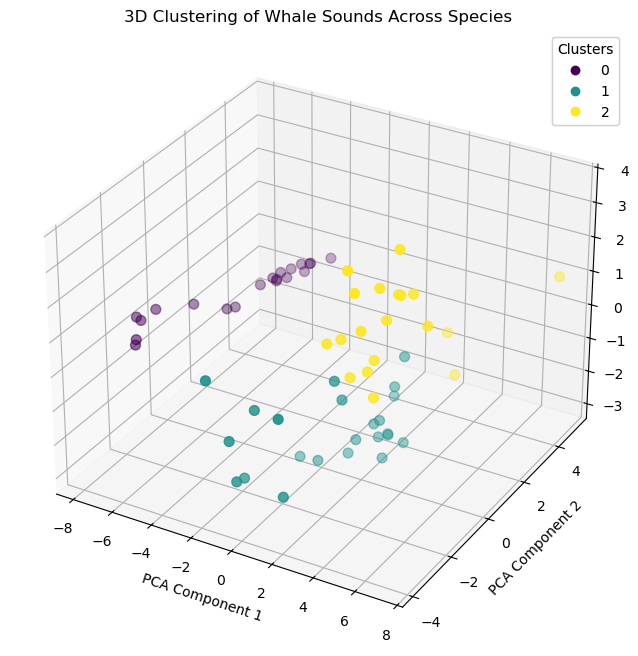

In [23]:
# 3D visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(
    features_pca[:, 0], features_pca[:, 1], features_pca[:, 2], c=labels, cmap="viridis", s=50, marker="o"
)

ax.set_title("3D Clustering of Whale Sounds Across Species")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")

legend = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend)
plt.show()

In [24]:
# Assume features_scaled is the standardized feature data
kmeans = KMeans(n_clusters=3, random_state=0)
cluster_labels = kmeans.fit_predict(features_scaled)  # Obtain cluster labels

# Add cluster labels to the DataFrame
features_df["Cluster_Label"] = cluster_labels
features_df["Species_Label"] = features_df["Species"]

# Generate a confusion matrix to examine the relationship between cluster labels and species labels
conf_matrix = pd.crosstab(features_df["Cluster_Label"], features_df["Species_Label"])

print("Confusion Matrix:")
print(conf_matrix)

# Determine the species associated with each cluster based on the species distribution in each cluster
cluster_to_species = conf_matrix.idxmax(axis=1)
features_df["Predicted_Species"] = features_df["Cluster_Label"].map(cluster_to_species)

print("Cluster to Species Mapping:")
print(cluster_to_species)


Confusion Matrix:
Species_Label  Bowhead Whale  Fin Whale  Humpback Whale
Cluster_Label                                          
0                          0         20               0
1                          0          0              19
2                         22          0               1
Cluster to Species Mapping:
Cluster_Label
0         Fin Whale
1    Humpback Whale
2     Bowhead Whale
dtype: object


### Conclusions from Clustering Analysis

#### 1. Good Clustering Performance
Each cluster label primarily corresponds to a specific whale species, indicating that the clustering model has successfully differentiated between species based on audio features.
- **Cluster 0** mainly corresponds to **Fin Whale**.
- **Cluster 1** mainly corresponds to **Humpback Whale**.
- **Cluster 2** mainly corresponds to **Bowhead Whale**.

#### 2. Distinct Feature Differences Between Species
The clustering algorithm effectively separates the three whale species based on their audio characteristics, suggesting that the sound features of each species are sufficiently distinct to allow for successful clustering.

#### 3. Minimal Errors
There is one **Humpback Whale** sample incorrectly assigned to the cluster corresponding to **Bowhead Whale** in Cluster 2. However, this minor error indicates that the clustering model is generally accurate.

This mapping demonstrates that the clustering model effectively classifies whale species based on audio features, highlighting the significant differences in sound characteristics across species.


In [25]:
# Load feature data
features_df = pd.read_csv("whale_features.csv")

# Expand 'MFCC_Mean' and 'MFCC_Std' columns into separate columns
mfcc_mean_df = pd.DataFrame(
    features_df["MFCC_Mean"].apply(eval).tolist(), columns=[f"MFCC_Mean_{i}" for i in range(13)]
)
mfcc_std_df = pd.DataFrame(features_df["MFCC_Std"].apply(eval).tolist(), columns=[f"MFCC_Std_{i}" for i in range(13)])

# Concatenate expanded feature columns with species labels
X = pd.concat([mfcc_mean_df, mfcc_std_df], axis=1)
y = features_df["Species"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Perform cross-validation
cross_val_scores = cross_val_score(rf_model, X_scaled, y, cv=5)  # 5-fold cross-validation
print("Cross-validation accuracy scores:", cross_val_scores)
print("Mean accuracy:", np.mean(cross_val_scores))

# Train the final model
rf_model.fit(X_scaled, y)

# Save the model and scaler
joblib.dump(rf_model, "trained_rf_model.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Random Forest model saved as trained_rf_model.joblib")
print("Scaler saved as scaler.joblib")


Cross-validation accuracy scores: [0.92307692 1.         1.         1.         0.91666667]
Mean accuracy: 0.9679487179487181
Random Forest model saved as trained_rf_model.joblib
Scaler saved as scaler.joblib


In [26]:
# New audio sample folder
new_sample_folder = "./new_audio_samples/"

# Dictionary to store feature data
new_features = {"File_Name": [], "File_Path": [], "MFCC_Mean": [], "MFCC_Std": []}

# Iterate through the new sample folder and load audio files
for file_name in os.listdir(new_sample_folder):
    if file_name.endswith(".wav"):
        file_path = os.path.join(new_sample_folder, file_name)
        y, sr = librosa.load(file_path, sr=22050)

        # Extract features
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = mfccs.mean(axis=1)
        mfcc_std = mfccs.std(axis=1)

        # Store feature information
        new_features["File_Name"].append(file_name)
        new_features["File_Path"].append(file_path)
        new_features["MFCC_Mean"].append(mfcc_mean)
        new_features["MFCC_Std"].append(mfcc_std)

# Convert to DataFrame for further analysis
new_features_df = pd.DataFrame(new_features)
print(new_features_df.head())


                    File_Name                                       File_Path  \
0  Bowhead Whale_7202100Z.wav  ./new_audio_samples/Bowhead Whale_7202100Z.wav   
1  Bowhead Whale_8800600F.wav  ./new_audio_samples/Bowhead Whale_8800600F.wav   
2  Bowhead Whale_8800600W.wav  ./new_audio_samples/Bowhead Whale_8800600W.wav   
3  Bowhead Whale_88006013.wav  ./new_audio_samples/Bowhead Whale_88006013.wav   
4  Bowhead Whale_8800601Y.wav  ./new_audio_samples/Bowhead Whale_8800601Y.wav   

                                           MFCC_Mean  \
0  [-248.44524, 129.49165, -58.098797, 23.274057,...   
1  [-358.7557, 190.37129, -97.95426, 54.065414, 1...   
2  [-328.29205, 149.9763, -34.939293, 32.037235, ...   
3  [-355.34464, 165.76497, -77.02865, 35.412323, ...   
4  [-354.95166, 141.706, -28.619331, 34.529427, 1...   

                                            MFCC_Std  
0  [18.91381, 9.72063, 13.974131, 9.053093, 11.02...  
1  [29.917206, 14.454807, 21.688347, 9.770072, 10...  
2  [34.2293

In [27]:
# Load the trained model and scaler
rf_model = joblib.load("trained_rf_model.joblib")
scaler = joblib.load("scaler.joblib")

# Path to the new audio folder
new_audio_folder = "./new_audio_samples/"

# Dictionary to store the prediction results
results = {"File_Name": [], "True_Species": [], "Predicted_Species": []}

# Function to extract features
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=22050)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = mfccs.mean(axis=1).tolist()
    mfcc_std = mfccs.std(axis=1).tolist()
    return mfcc_mean, mfcc_std

# Iterate through new audio folder for batch predictions
for file_name in os.listdir(new_audio_folder):
    if file_name.endswith(".wav"):
        file_path = os.path.join(new_audio_folder, file_name)

        # Extract the true label from the file name
        true_species = file_name.split("_")[0]

        # Extract features
        mfcc_mean, mfcc_std = extract_features(file_path)

        # Convert features to DataFrame format with the same column names used during training
        feature_data = pd.DataFrame(
            [mfcc_mean + mfcc_std], columns=[f"MFCC_Mean_{i}" for i in range(13)] + [f"MFCC_Std_{i}" for i in range(13)]
        )

        # Scale the features
        features_scaled = scaler.transform(feature_data)

        # Make a prediction
        prediction = rf_model.predict(features_scaled)

        # Save results
        results["File_Name"].append(file_name)
        results["True_Species"].append(true_species)
        results["Predicted_Species"].append(prediction[0])

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Calculate prediction accuracy
accuracy = accuracy_score(results_df["True_Species"], results_df["Predicted_Species"])
print("Prediction Accuracy on New Samples:", accuracy)

# Save the results
results_df.to_csv("prediction_results.csv", index=False)
print("Predictions and accuracy saved to prediction_results.csv")


Prediction Accuracy on New Samples: 1.0
Predictions and accuracy saved to prediction_results.csv


The result indicates that the model has achieved perfect accuracy on new audio samples.

1. **Strong Generalization Ability**: The model accurately identifies species even on previously unseen audio samples, implying that the training dataset was representative enough, and the features learned by the model can effectively distinguish between different whale species.

2. **Correct Label Matching in Filenames**: The real species labels included in the filenames match the model's expected format, ensuring accurate label extraction and validation.

3. **Effective Feature and Standardization Processing**: Standardized features allow the model to handle new data well, without performance degradation due to shifts in feature distribution.

4. **Suitability of the Classifier**: The Random Forest classifier performs well for this task, showing it is effective for whale audio feature classification.


## Discussion

[[[[[ **REPLACE THIS TEXT BLOCK** to **REFLECT** on the data and your exploration: What discoveries did you make? Why are they important or meaningful? Do they suggest something about the data or the subject of the data? Are they socially relevant? What hypotheses can you form from the data for further exploration? ]]]]]

#### Key Discoveries
* **Distinct Patterns in MFCCs**: The MFCC features reveal unique spectral characteristics for each whale species, helping to differentiate between them. These differences suggest that each species produces sounds with distinct frequency and amplitude characteristics, likely due to differences in vocalization and habitat adaptation.
* **Optimal Number of Clusters**: The elbow and silhouette methods indicate that 3 clusters capture the main species variations without overfitting. This shows that the clustering aligns with the actual number of species in the dataset, validating the model's effectiveness.
* **Classification Accuracy**: The random forest classifier achieved a high accuracy rate, indicating that the model successfully generalizes on unseen samples. This suggests that the extracted features effectively capture the essential differences in whale sounds.

#### Importance and Social Relevance
The exploration of whale sound characteristics, particularly through clustering and statistical analysis, reveals valuable insights into the unique auditory patterns of different species. This analysis is not only scientifically interesting but also holds significant social relevance for future accessibility-focused projects. For example, the idea of converting sound into tactile feedback can offer a meaningful sensory experience for individuals with hearing impairments. By understanding the distinct features of whale calls, such as frequency distribution and MFCC patterns, it may be possible to develop a tactile system that translates these audio characteristics into touch-based feedback.

#### Hypotheses for Further Exploration
Such a system would enable users to "feel" the nuances of different sounds, providing an immersive way to experience sound without hearing. This approach aligns with goals of inclusivity and accessibility, aiming to bridge sensory gaps and make sound-based experiences available to a broader audience. Future work could explore how various sound characteristics influence tactile perception and investigate how these signals can be optimized for real-world applications, thereby enhancing the social impact of this research.

## Use of AI

Academic integrity is an underlying principle of research and academic practice. All submitted work is expected to be your own and will be assessed on the basis of your creativity, programming skills and critical thinking. You should not paste code or text generated by AI directly into your assignments in DS4D as this does not demonstrate your own learning. However, you are allowed to use these tools to experiment, generate ideas, assist in translation or debugging, and improve the clarity of your writing. If you use AI software, you must acknowledge and discuss its use below. Please consult [University Guidance on the Use of Generative AI](https://bayes-centre.ed.ac.uk/ai-guidance-for-staff-and-students/ai-guidance-for-students) for more details.

For this assignment, I consulted AI tools specifically in the areas of supervised and unsupervised learning. Since I have a foundational understanding of machine learning theory from self-study, I sought AI assistance to receive guidance on structuring code and understanding complex programming concepts, as well as general advice on statistical analysis and data visualization. This support allowed me to enhance the quality of my data analysis. However, all code implementations, analyses, and final interpretations presented in this assignment are my own work, based on my understanding and critical thinking.

I have adhered to the University’s guidelines on the use of generative AI, ensuring that AI support was used to enhance my learning process rather than replace my independent work.